# BARRA-RE2 all-realization wind drought frequency comparison with ERA5

This notebook plots **ERA5 plus all 22 BARRA-RE2 realizations** in one multi-panel figure.

No BARRA ensemble mean is used in the figure. Each BARRA panel is one realization.

Workflow:
1. Read yearly binary wind-drought masks.
2. Sum drought days per year.
3. Compute 1990 to 2025 climatological annual drought days.
4. Keep BARRA-RE2 realizations separate.
5. Plot ERA5 + all BARRA-RE2 realizations in one figure using the same frequency-map style.


In [1]:
import os
from glob import glob
from pathlib import Path

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from tqdm.auto import tqdm


In [2]:
# =====================
# Settings
# =====================
BARRA_INPUT_DIR = "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly"
ERA5_INPUT_DIR = "/g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5"

OUTPUT_DIR = "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/all_realization_comparison"
os.makedirs(OUTPUT_DIR, exist_ok=True)

START_YEAR = 1990
END_YEAR = 2025

lon_min, lon_max = 110, 160
lat_min, lat_max = -45, -10

threshold_percentile = 20
persistence_days = 3

BARRA_PATTERN = "wind_drought_P20_3day_*.nc"
ERA5_PATTERN = "wind_drought_P20_3day_*.nc"

# Same style as the ERA5 frequency template
levels = np.arange(3, 42, 3)

OUT_BARRA_NC = os.path.join(
    OUTPUT_DIR,
    "BARRA_RE2_P20_3day_climatological_wind_drought_days_ALL_REALIZATIONS_1990_2025.nc"
)

OUT_ERA5_NC = os.path.join(
    OUTPUT_DIR,
    "ERA5_P20_3day_climatological_wind_drought_days_1990_2025.nc"
)

OUT_FIG = os.path.join(
    OUTPUT_DIR,
    "ERA5_plus_BARRA_RE2_all_realizations_wind_drought_frequency_1990_2025.png"
)

print("Output directory:", OUTPUT_DIR)


Output directory: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/all_realization_comparison


In [3]:
# =====================
# Helper functions
# =====================
def year_from_filename(fp):
    return int(os.path.basename(fp).split("_")[-1].split(".")[0])


def get_year_files(input_dir, pattern, start_year, end_year):
    files = sorted(glob(os.path.join(input_dir, pattern)))
    out = []
    for fp in files:
        yr = year_from_filename(fp)
        if start_year <= yr <= end_year:
            out.append(fp)
    if len(out) == 0:
        raise FileNotFoundError(f"No files found in {input_dir} for {start_year}-{end_year}")
    return out


def get_var_name(ds):
    if "wind_drought" in ds.data_vars:
        return "wind_drought"
    return list(ds.data_vars)[0]


def get_lon_lat_names(obj):
    names = list(obj.coords) + list(obj.dims)

    if "lon" in names:
        lon_name = "lon"
    elif "longitude" in names:
        lon_name = "longitude"
    else:
        raise KeyError("Could not find lon or longitude coordinate")

    if "lat" in names:
        lat_name = "lat"
    elif "latitude" in names:
        lat_name = "latitude"
    else:
        raise KeyError("Could not find lat or latitude coordinate")

    return lon_name, lat_name


def crop_australia(da):
    lon_name, lat_name = get_lon_lat_names(da)
    lon = da[lon_name]
    lat = da[lat_name]

    return da.where(
        (lon >= lon_min) & (lon <= lon_max) &
        (lat >= lat_min) & (lat <= lat_max),
        drop=True
    )


def standardise_for_plot(da):
    # Return DataArray as latitude, longitude for contourf.
    rename = {}

    if "lon" in da.dims:
        rename["lon"] = "longitude"
    if "lat" in da.dims:
        rename["lat"] = "latitude"
    if "lon" in da.coords:
        rename["lon"] = "longitude"
    if "lat" in da.coords:
        rename["lat"] = "latitude"

    if rename:
        da = da.rename(rename)

    # Remove non-spatial singleton dimensions if any
    for d in list(da.dims):
        if d not in ["latitude", "longitude"]:
            if da.sizes[d] == 1:
                da = da.isel({d: 0}, drop=True)
            else:
                raise ValueError(f"Unexpected non-spatial dimension for plotting: {d}")

    da = da.transpose("latitude", "longitude")
    return da


In [4]:
# =====================
# Find files
# =====================
barra_files = get_year_files(BARRA_INPUT_DIR, BARRA_PATTERN, START_YEAR, END_YEAR)
era5_files = get_year_files(ERA5_INPUT_DIR, ERA5_PATTERN, START_YEAR, END_YEAR)

print("BARRA files:", len(barra_files))
print("BARRA first:", barra_files[0])
print("BARRA last :", barra_files[-1])

print("ERA5 files:", len(era5_files))
print("ERA5 first:", era5_files[0])
print("ERA5 last :", era5_files[-1])


BARRA files: 36
BARRA first: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_1990.nc
BARRA last : /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_2025.nc
ERA5 files: 36
ERA5 first: /g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5/wind_drought_P20_3day_1990.nc
ERA5 last : /g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5/wind_drought_P20_3day_2025.nc


In [6]:
# =====================
# Inspect one BARRA and one ERA5 file
# =====================
with xr.open_dataset(barra_files[0], engine="netcdf4", decode_times=True) as ds0:
    barra_var = get_var_name(ds0)
    print("BARRA dataset:")
    print(ds0)
    print("BARRA variable:", barra_var)
    print("BARRA dims:", ds0[barra_var].dims)
    print("BARRA shape:", ds0[barra_var].shape)

with xr.open_dataset(era5_files[0], engine="netcdf4", decode_times=True) as ds0:
    era5_var = get_var_name(ds0)
    print("ERA5 dataset:")
    print(ds0)
    print("ERA5 variable:", era5_var)
    print("ERA5 dims:", ds0[era5_var].dims)
    print("ERA5 shape:", ds0[era5_var].shape)


BARRA dataset:
<xarray.Dataset> Size: 1GB
Dimensions:       (time: 365, realization: 22, lon: 227, lat: 159)
Coordinates:
  * time          (time) datetime64[ns] 3kB 1990-01-01T12:00:00 ... 1990-12-3...
  * realization   (realization) <U5 440B '000_0' '000_1' ... 'ctl_0' 'ctl_1'
  * lon           (lon) float64 2kB 110.2 110.4 110.7 ... 159.5 159.7 159.9
  * lat           (lat) float64 1kB -44.83 -44.61 -44.39 ... -10.29 -10.07
Data variables:
    wind_drought  (time, realization, lon, lat) float32 1GB ...
Attributes:
    title:    BARRA-RE2 wind drought mask for 1990
    history:  Created from monthly wind100 files using fixed 1991-2020 P20 th...
    region:   Australia
    lon_min:  110
    lon_max:  160
    lat_min:  -45
    lat_max:  -10
BARRA variable: wind_drought
BARRA dims: ('time', 'realization', 'lon', 'lat')
BARRA shape: (365, 22, 227, 159)
ERA5 dataset:
<xarray.Dataset> Size: 10MB
Dimensions:       (time: 365, latitude: 141, longitude: 201)
Coordinates:
  * time          (ti

In [7]:
# =====================
# Compute BARRA-RE2 climatological annual drought days for EACH realization
# No ensemble mean is used here.
# =====================
barra_annual_list = []
barra_years = []
realization_values = None

for fp in tqdm(barra_files, desc="BARRA yearly files"):
    year = year_from_filename(fp)

    ds = xr.open_dataset(fp, engine="netcdf4", decode_times=True)
    wd = ds[barra_var]

    # Crop Australia
    wd = crop_australia(wd)

    # Sum annual drought days for each realization separately
    days = wd.sum(dim="time", skipna=True).astype("float32")
    days.name = "annual_wind_drought_days"
    days.attrs["units"] = "days/year"
    days.attrs["realization_handling"] = "BARRA-RE2 realizations kept separate, no ensemble mean"

    if realization_values is None and "realization" in days.coords:
        realization_values = days["realization"].values

    barra_annual_list.append(days.load())
    barra_years.append(year)

    ds.close()

barra_annual = xr.concat(barra_annual_list, dim="year")
barra_annual = barra_annual.assign_coords(year=barra_years)
barra_annual.name = "annual_wind_drought_days_by_realization"

# Mean over years only, not over realizations
barra_clim_by_realization = barra_annual.mean(dim="year", skipna=True).astype("float32")
barra_clim_by_realization.name = "climatological_wind_drought_days_by_realization"
barra_clim_by_realization.attrs["long_name"] = "Climatological annual wind drought days for each BARRA-RE2 realization"
barra_clim_by_realization.attrs["units"] = "days/year"
barra_clim_by_realization.attrs["period"] = f"{START_YEAR}-{END_YEAR}"
barra_clim_by_realization.attrs["realization_handling"] = "Each realization plotted separately. No ensemble mean."

print(barra_annual)
print(barra_clim_by_realization)


BARRA yearly files:   0%|          | 0/36 [00:00<?, ?it/s]

<xarray.DataArray 'annual_wind_drought_days_by_realization' (year: 36,
                                                             realization: 22,
                                                             lon: 227, lat: 159)> Size: 114MB
array([[[[25., 25., 29., ..., 63., 64., 61.],
         [25., 29., 29., ..., 62., 63., 68.],
         [28., 29., 29., ..., 63., 64., 66.],
         ...,
         [19., 18., 15., ..., 27., 27., 23.],
         [23., 15., 13., ..., 29., 26., 23.],
         [17., 15., 12., ..., 29., 19., 24.]],

        [[26., 26., 30., ..., 65., 65., 71.],
         [26., 30., 32., ..., 65., 65., 71.],
         [27., 32., 32., ..., 70., 73., 71.],
         ...,
         [22., 21., 18., ..., 30., 32., 29.],
         [22., 15., 12., ..., 36., 35., 31.],
         [15., 12., 12., ..., 32., 27., 30.]],

        [[23., 23., 20., ..., 58., 60., 66.],
         [25., 20., 17., ..., 58., 64., 64.],
         [25., 20., 24., ..., 62., 66., 65.],
         ...,
...
         [ 9., 16

In [8]:
# =====================
# Save BARRA all-realization output
# =====================
barra_out_ds = xr.Dataset(
    {
        "annual_wind_drought_days_by_realization": barra_annual,
        "climatological_wind_drought_days_by_realization": barra_clim_by_realization,
    }
)

barra_out_ds.attrs["title"] = "BARRA-RE2 wind drought frequency, all realizations"
barra_out_ds.attrs["description"] = (
    "Annual wind drought days and 1990-2025 climatological annual drought days. "
    "BARRA-RE2 realizations are kept separate. No ensemble mean is applied."
)
barra_out_ds.attrs["threshold"] = f"P{threshold_percentile}"
barra_out_ds.attrs["duration"] = f">= {persistence_days} consecutive days"
barra_out_ds.attrs["period"] = f"{START_YEAR}-{END_YEAR}"
barra_out_ds.attrs["input_dir"] = BARRA_INPUT_DIR

encoding = {
    "annual_wind_drought_days_by_realization": {
        "zlib": True,
        "complevel": 4,
        "shuffle": True,
        "dtype": "float32",
    },
    "climatological_wind_drought_days_by_realization": {
        "zlib": True,
        "complevel": 4,
        "shuffle": True,
        "dtype": "float32",
    },
}

barra_out_ds.to_netcdf(OUT_BARRA_NC, encoding=encoding)
print("Saved BARRA all-realization NetCDF:", OUT_BARRA_NC)


Saved BARRA all-realization NetCDF: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/all_realization_comparison/BARRA_RE2_P20_3day_climatological_wind_drought_days_ALL_REALIZATIONS_1990_2025.nc


In [9]:
# =====================
# Compute ERA5 climatological annual drought days
# =====================
era5_annual_list = []
era5_years = []

for fp in tqdm(era5_files, desc="ERA5 yearly files"):
    year = year_from_filename(fp)

    ds = xr.open_dataset(fp, engine="netcdf4", decode_times=True)
    wd = ds[era5_var]

    # Crop Australia, safe if file already covers region
    wd = crop_australia(wd)

    # Annual drought days
    days = wd.sum(dim="time", skipna=True).astype("float32")
    days.name = "annual_wind_drought_days"
    days.attrs["units"] = "days/year"

    era5_annual_list.append(days.load())
    era5_years.append(year)

    ds.close()

era5_annual = xr.concat(era5_annual_list, dim="year")
era5_annual = era5_annual.assign_coords(year=era5_years)
era5_annual.name = "annual_wind_drought_days"

era5_clim = era5_annual.mean(dim="year", skipna=True).astype("float32")
era5_clim.name = "climatological_wind_drought_days"
era5_clim.attrs["long_name"] = "ERA5 climatological annual wind drought days"
era5_clim.attrs["units"] = "days/year"
era5_clim.attrs["period"] = f"{START_YEAR}-{END_YEAR}"

print(era5_annual)
print(era5_clim)


ERA5 yearly files:   0%|          | 0/36 [00:00<?, ?it/s]

<xarray.DataArray 'annual_wind_drought_days' (year: 36, latitude: 141,
                                              longitude: 201)> Size: 4MB
array([[[48., 50., 50., ..., 30., 37., 47.],
        [47., 44., 39., ..., 37., 38., 47.],
        [42., 44., 43., ..., 37., 38., 48.],
        ...,
        [19., 19., 19., ..., 22., 22., 22.],
        [16., 16., 19., ..., 19., 19., 19.],
        [13., 13., 13., ..., 16., 16., 19.]],

       [[73., 72., 71., ..., 27., 36., 33.],
        [69., 64., 72., ..., 40., 44., 46.],
        [67., 68., 68., ..., 42., 44., 43.],
        ...,
        [45., 44., 41., ..., 13., 12., 16.],
        [41., 41., 41., ..., 20., 22., 13.],
        [44., 41., 41., ..., 19., 19., 19.]],

       [[85., 82., 80., ..., 29., 34., 28.],
        [81., 78., 79., ..., 35., 37., 39.],
        [83., 80., 78., ..., 35., 33., 38.],
        ...,
...
        [33., 37., 35., ..., 10., 10., 11.],
        [29., 32., 32., ..., 13., 13., 11.],
        [23., 19., 19., ..., 10., 13., 17.]]

In [10]:
# =====================
# Save ERA5 output
# =====================
era5_out_ds = xr.Dataset(
    {
        "annual_wind_drought_days": era5_annual,
        "climatological_wind_drought_days": era5_clim,
    }
)

era5_out_ds.attrs["title"] = "ERA5 wind drought frequency"
era5_out_ds.attrs["description"] = "Annual wind drought days and 1990-2025 climatological annual drought days."
era5_out_ds.attrs["threshold"] = f"P{threshold_percentile}"
era5_out_ds.attrs["duration"] = f">= {persistence_days} consecutive days"
era5_out_ds.attrs["period"] = f"{START_YEAR}-{END_YEAR}"
era5_out_ds.attrs["input_dir"] = ERA5_INPUT_DIR

encoding = {
    "annual_wind_drought_days": {
        "zlib": True,
        "complevel": 4,
        "shuffle": True,
        "dtype": "float32",
    },
    "climatological_wind_drought_days": {
        "zlib": True,
        "complevel": 4,
        "shuffle": True,
        "dtype": "float32",
    },
}

era5_out_ds.to_netcdf(OUT_ERA5_NC, encoding=encoding)
print("Saved ERA5 NetCDF:", OUT_ERA5_NC)


Saved ERA5 NetCDF: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/all_realization_comparison/ERA5_P20_3day_climatological_wind_drought_days_1990_2025.nc


In [11]:
# =====================
# Prepare data for plotting
# =====================
era5_plot = standardise_for_plot(era5_clim)

# BARRA plotting fields, one DataArray per realization
barra_plot_fields = []
realization_labels = []

n_real = barra_clim_by_realization.sizes["realization"]

for i in range(n_real):
    da_i = barra_clim_by_realization.isel(realization=i)
    da_i = standardise_for_plot(da_i)
    barra_plot_fields.append(da_i)

    if "realization" in barra_clim_by_realization.coords:
        realization_labels.append(str(barra_clim_by_realization["realization"].values[i]))
    else:
        realization_labels.append(str(i))

print("ERA5 plot dims:", era5_plot.dims, era5_plot.shape)
print("Number of BARRA realizations:", len(barra_plot_fields))
print("First BARRA plot dims:", barra_plot_fields[0].dims, barra_plot_fields[0].shape)
print("Realization labels:", realization_labels)


ERA5 plot dims: ('latitude', 'longitude') (141, 201)
Number of BARRA realizations: 22
First BARRA plot dims: ('latitude', 'longitude') (159, 227)
Realization labels: ['000_0', '000_1', '001_0', '001_1', '002_0', '002_1', '003_0', '003_1', '004_0', '004_1', '005_0', '005_1', '006_0', '006_1', '007_0', '007_1', '008_0', '008_1', '009_0', '009_1', 'ctl_0', 'ctl_1']


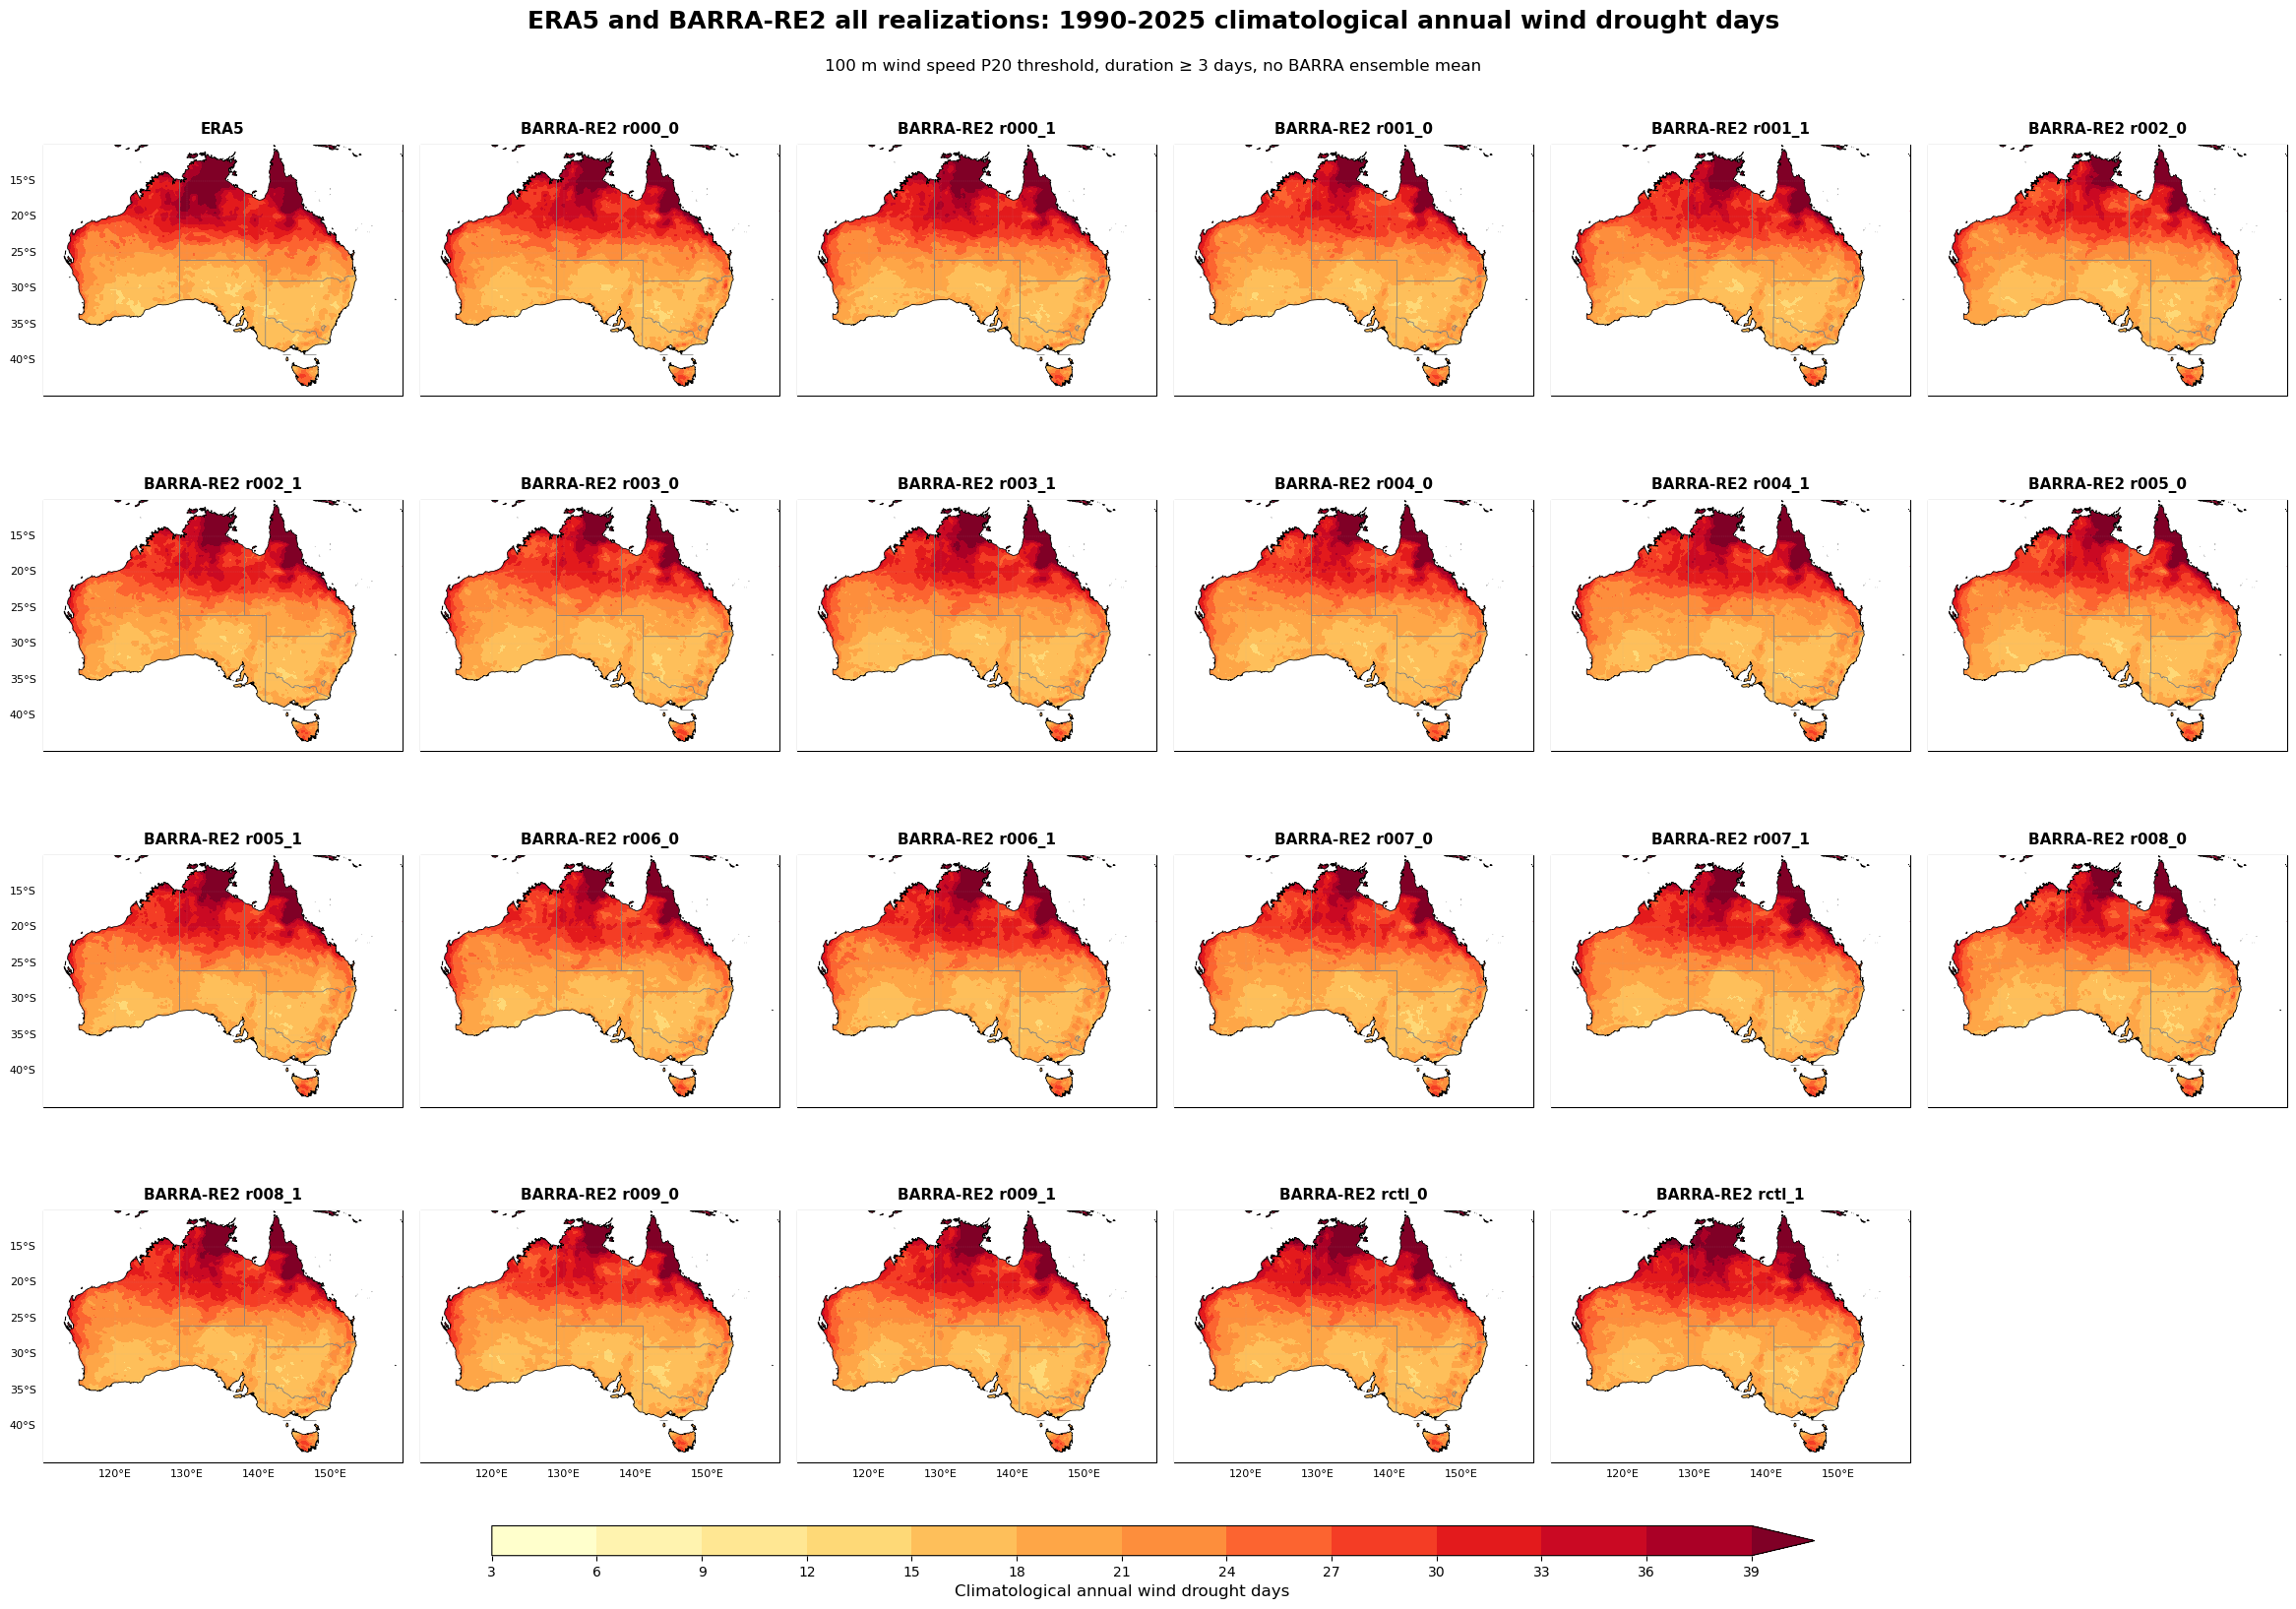

Saved figure: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/all_realization_comparison/ERA5_plus_BARRA_RE2_all_realizations_wind_drought_frequency_1990_2025.png


In [12]:
# =====================
# One figure: ERA5 + all BARRA-RE2 realizations
# =====================
cmap = plt.cm.YlOrRd.copy()
cmap.set_under("white")
cmap.set_bad("white")

norm = mcolors.BoundaryNorm(
    levels,
    cmap.N,
    extend="max"
)

# 1 ERA5 + 22 BARRA = 23 panels. Use 4 x 6 = 24 slots.
n_panels = 1 + len(barra_plot_fields)
ncols = 6
nrows = int(np.ceil(n_panels / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(24, 4.2 * nrows),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=False
)

axes = np.asarray(axes).ravel()

states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    scale="10m",
    facecolor="none"
)

panel_data = [("ERA5", era5_plot)]
for label, da in zip(realization_labels, barra_plot_fields):
    panel_data.append((f"BARRA-RE2 r{label}", da))

cf = None

for idx, (title, da) in enumerate(panel_data):
    ax = axes[idx]

    cf = ax.contourf(
        da["longitude"],
        da["latitude"],
        da,
        levels=levels,
        cmap=cmap,
        norm=norm,
        extend="max",
        transform=ccrs.PlateCarree()
    )

    ax.add_feature(
        cfeature.OCEAN,
        facecolor="white",
        edgecolor="none",
        zorder=100
    )

    ax.coastlines(
        resolution="10m",
        linewidth=0.55,
        color="black",
        zorder=101
    )

    ax.add_feature(
        states,
        edgecolor="grey",
        linewidth=0.55,
        zorder=102
    )

    ax.set_extent(
        [lon_min, lon_max, lat_min, lat_max],
        crs=ccrs.PlateCarree()
    )

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.25,
        linestyle="--",
        alpha=0.35
    )

    gl.top_labels = False
    gl.right_labels = False

    # Keep labels only on outer panels to avoid clutter
    row = idx // ncols
    col = idx % ncols
    gl.left_labels = (col == 0)
    gl.bottom_labels = (row == nrows - 1)

    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}

    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)

# Hide empty panels
for j in range(n_panels, len(axes)):
    axes[j].axis("off")

# Shared colorbar
cbar_ax = fig.add_axes([0.22, 0.05, 0.56, 0.018])
cbar = fig.colorbar(
    cf,
    cax=cbar_ax,
    orientation="horizontal"
)

cbar.set_label("Climatological annual wind drought days", fontsize=12)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=10)

fig.suptitle(
    "ERA5 and BARRA-RE2 all realizations: 1990-2025 climatological annual wind drought days",
    fontsize=18,
    fontweight="bold",
    y=0.985
)

fig.text(
    0.5,
    0.955,
    "100 m wind speed P20 threshold, duration ≥ 3 days, no BARRA ensemble mean",
    ha="center",
    va="top",
    fontsize=12
)

plt.subplots_adjust(
    left=0.03,
    right=0.98,
    top=0.92,
    bottom=0.09,
    wspace=0.05,
    hspace=0.16
)

plt.savefig(
    OUT_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved figure:", OUT_FIG)


In [ ]:
# =====================
# Quick check saved files
# =====================
print("Saved figure:", OUT_FIG)
print("Saved BARRA all-realization data:", OUT_BARRA_NC)
print("Saved ERA5 data:", OUT_ERA5_NC)

print("
BARRA output:")
with xr.open_dataset(OUT_BARRA_NC, engine="netcdf4") as check:
    print(check)

print("
ERA5 output:")
with xr.open_dataset(OUT_ERA5_NC, engine="netcdf4") as check:
    print(check)
